In [1]:
from pathlib import Path
import hashlib
import json
import os
import subprocess
from datetime import datetime, timezone
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from dotenv import load_dotenv
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Run from the project root or its Fei folder.
ROOT = Path.cwd()
if ROOT.name.lower() == "fei":
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Run from the project root or Fei folder."

DATA = ROOT / "Fei" / "local" / "spatial_pilot"
MONTH = "2025-01"
RADIUS_M = 100
assert RADIUS_M > 0, "Radius must be positive."
OUTPUT = ROOT / "Fei" / "outputs" / f"simple_{MONTH}_{RADIUS_M}m"
load_dotenv(ROOT / ".env")


False

In [14]:
import sys
print(sys.executable)

/Users/xuefei/Desktop/Group-7-Capstone/.venv/bin/python


In [2]:
def download_crash_month(month):
    # 1. Turn a month such as "2025-01" into [Jan 1, Feb 1).
    period = pd.Period(month, freq="M")
    start, end = period.start_time, (period + 1).start_time
    stem = f"crashes_{start:%Y%m%d}_{end:%Y%m%d}"
    data_file = DATA / f"{stem}.parquet"
    receipt_file = DATA / f"{stem}_receipt.json"

    # 2. Reuse this month's cache only when the file and receipt agree.
    if data_file.exists() and receipt_file.exists():
        receipt = json.loads(receipt_file.read_text())
        assert receipt["dataset_id"] == "h9gi-nx95"
        assert receipt["start"] == str(start.date()) and receipt["end_exclusive"] == str(end.date())
        assert hashlib.sha256(data_file.read_bytes()).hexdigest() == receipt["sha256"], "Cache changed."
        raw = pd.read_parquet(data_file)
        assert len(raw) == receipt["rows"]
        assert raw.collision_id.notna().all() and raw.collision_id.is_unique
        assert pd.to_datetime(raw.crash_date).between(start, end, inclusive="left").all()
        print(f"{month}: read {len(raw):,} cached crashes")
        return raw, receipt

    # 3. Retry temporary API failures; the token is optional for this endpoint.
    session = requests.Session()
    session.mount("https://", HTTPAdapter(max_retries=Retry(total=4, backoff_factor=2,
        status_forcelist=[429, 500, 502, 503, 504], allowed_methods=["GET"])))
    if os.getenv("SOCRATA_APP_TOKEN"):
        session.headers["X-App-Token"] = os.environ["SOCRATA_APP_TOKEN"]
    base = "https://data.cityofnewyork.us/"
    where = f"crash_date >= '{start:%Y-%m-%dT00:00:00}' AND crash_date < '{end:%Y-%m-%dT00:00:00}'"
    count_query = {"$select": "count(*) AS n", "$where": where}
    records, offset, page_size = [], 0, 5000
    with session:
        # A tiny helper keeps HTTP error handling identical for every request.
        def get(path, params=None):
            response = session.get(base + path, params=params, timeout=(20, 120))
            response.raise_for_status()
            return response.json()

        before = get("api/views/h9gi-nx95.json")["rowsUpdatedAt"]
        expected = int(get("resource/h9gi-nx95.json", count_query)[0]["n"])
        # 4. Keep requesting the next page, not just the first 5,000 records.
        while True:
            page = get("resource/h9gi-nx95.json", {"$where": where,
                "$order": "collision_id", "$limit": page_size, "$offset": offset})
            if not page:
                break
            records.extend(page)
            offset += len(page)
            print(f"{month}: downloaded {offset:,} rows")
            if offset > expected:
                raise RuntimeError("Source count changed during download; retry this month.")
        final_count = int(get("resource/h9gi-nx95.json", count_query)[0]["n"])
        after = get("api/views/h9gi-nx95.json")["rowsUpdatedAt"]

    # 5. Validate before saving. Never mark an interrupted month as complete.
    raw = pd.DataFrame(records)
    assert before == after, "Source changed during download; retry this month."
    assert len(raw) == expected == final_count, "Incomplete month; retry."
    assert not raw.empty, "No records: check the requested month."
    assert raw.collision_id.notna().all() and raw.collision_id.is_unique
    assert pd.to_datetime(raw.crash_date).between(start, end, inclusive="left").all()

    # 6. Save raw data unchanged, plus the query, source time and file fingerprint.
    DATA.mkdir(parents=True, exist_ok=True)
    temporary_file = DATA / f"{stem}.part.parquet"
    raw.to_parquet(temporary_file, index=False)
    temporary_file.replace(data_file)
    receipt = {"dataset_id": "h9gi-nx95", "where": where, "order": "collision_id",
        "page_size": page_size, "rows": len(raw), "source_rows_updated_at": before,
        "start": str(start.date()), "end_exclusive": str(end.date()),
        "pulled_at": datetime.now(timezone.utc).isoformat(),
        "sha256": hashlib.sha256(data_file.read_bytes()).hexdigest()}
    receipt_file.write_text(json.dumps(receipt, indent=2))
    return raw, receipt


In [3]:
DOWNLOAD_HISTORY = False
FIRST_MONTH = "2017-01"
LAST_MONTH = "2025-12"

if DOWNLOAD_HISTORY:
    first = pd.Period(FIRST_MONTH, freq="M")
    last = pd.Period(LAST_MONTH, freq="M")
    assert first <= last
    current_month = pd.Timestamp.now(tz="America/New_York").tz_localize(None).to_period("M")
    assert last < current_month, "Choose a completed month, not the current or future month."
    for month in pd.period_range(first, last, freq="M"):
        monthly_data, monthly_receipt = download_crash_month(str(month))
        print(f"Ready: {month}, {len(monthly_data):,} records")
        del monthly_data  # Release this month before reading the next one.
else:
    print("Historical batch disabled. The next cell loads only MONTH.")


Historical batch disabled. The next cell loads only MONTH.


In [4]:
# Reuse Eric's local candidate CSV, or copy the pinned original from local Git.
DATA.mkdir(parents=True, exist_ok=True)
camera_file = DATA / "eric_camera_coordinates.csv"
if not camera_file.exists():
    source = "31cdadc1aa78cda8438612effa2a900b9f31a629:data/nyc_camera_coordinates.csv"
    camera_file.write_bytes(subprocess.check_output(["git", "show", source], cwd=ROOT))
sites_raw = pd.read_csv(camera_file)

# Read the chosen month's cache, or download it if it does not exist.
crashes_raw, receipt = download_crash_month(MONTH)
print("Candidate location records:", len(sites_raw))
print("Crash records:", len(crashes_raw))
print("Downloaded at:", receipt["pulled_at"])
display(crashes_raw.head(3))


2025-01: read 6,482 cached crashes
Candidate location records: 2650
Crash records: 6482
Downloaded at: 2026-10-08T04:03:55.121273+00:00


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,number_of_persons_injured,...,vehicle_type_code1,contributing_factor_vehicle_2,vehicle_type_code2,cross_street_name,contributing_factor_vehicle_3,contributing_factor_vehicle_4,vehicle_type_code_3,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2025-01-07T00:00:00.000,11:51,QUEENS,11357,40.779884,-73.80321,"{'latitude': '40.779884', 'longitude': '-73.80...",160 STREET,WILLETS POINT BOULEVARD,1,...,Sedan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01T00:00:00.000,0:44,BRONX,10474,40.810886,-73.88166,"{'latitude': '40.810886', 'longitude': '-73.88...",OAK POINT AVE,HUNTS POINT AVE,0,...,Sedan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01T00:00:00.000,2:55,BROOKLYN,11207,40.658577,-73.890625,"{'latitude': '40.658577', 'longitude': '-73.89...",LINDEN BLVD,PENNSYLVANIA AVE,0,...,Station Wagon/Sport Utility Vehicle,Unspecified,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
crashes = crashes_raw.copy()
assert crashes.collision_id.notna().all() and crashes.collision_id.is_unique
crashes["longitude"] = pd.to_numeric(crashes.longitude, errors="coerce")
crashes["latitude"] = pd.to_numeric(crashes.latitude, errors="coerce")

valid = crashes.longitude.between(-74.30, -73.65) & crashes.latitude.between(40.45, 40.95)
rejected_crashes = crashes.loc[~valid].copy()
crashes = crashes.loc[valid].copy()
crashes["injured"] = pd.to_numeric(crashes.number_of_persons_injured, errors="coerce")
crashes["killed"] = pd.to_numeric(crashes.number_of_persons_killed, errors="coerce")
assert crashes[["injured", "killed"]].dropna().ge(0).all().all()
print("Usable crashes:", len(crashes), "| Excluded:", len(rejected_crashes))

Usable crashes: 6265 | Excluded: 217


In [6]:
sites = sites_raw.copy()
assert sites.Clean_Intersection.notna().all() and sites.Clean_Intersection.is_unique
sites["site_id"] = sites.Clean_Intersection.map(
    lambda text: "site_" + hashlib.sha256(text.encode()).hexdigest()[:16])
assert sites.site_id.is_unique
sites["Longitude"] = pd.to_numeric(sites.Longitude, errors="coerce")
sites["Latitude"] = pd.to_numeric(sites.Latitude, errors="coerce")
valid = sites.Longitude.between(-74.30, -73.65) & sites.Latitude.between(40.45, 40.95)
rejected_sites = sites.loc[~valid].copy()
sites = sites.loc[valid].copy()

shared_sites = sites[sites.duplicated(["Latitude", "Longitude"], keep=False)].copy()
shared_groups = shared_sites.groupby(["Latitude", "Longitude"]).agg(
    records=("site_id", "size"), location_texts=("Clean_Intersection", list)).reset_index()
print("Usable sites:", len(sites), "| Excluded:", len(rejected_sites))
print("Shared-coordinate records:", len(shared_sites), "| Groups:", len(shared_groups))
display(rejected_sites[["Clean_Intersection", "Latitude", "Longitude"]])
display(shared_groups.head(10))

Usable sites: 2637 | Excluded: 13
Shared-coordinate records: 273 | Groups: 123


,Clean_Intersection,Latitude,Longitude
2149,"BRUCKNER BLVD. WILLIS AVE - LINCOLN A, NYC",44.721053,-83.513967
2226,"FALCON AVE. ADELAIDE AVE - PENN AVE, NYC",-35.077689,138.504878
2301,"MERRICK BV. LINDEN BLVD - 116 AV, NYC",40.656416,-73.551910
2338,"LIBERTY AVE. CLEVELAND ST - ESSEX ST, NYC",41.441536,-81.781882
2346,"ALBANY AVE. ATLANTIC AV- PARK PL, NYC",39.353807,-74.456735
2358,"LINCOLN AV -- KISWICK ST - BOUNDARY A, NYC",53.208989,-0.551363
2401,"FULTON ST. LEWISAV- UTICA AV, NYC",43.101552,-75.227009
2449,"CPL. KENNEDY ST.34TH AVE - 32ND AVE, NYC",52.974173,-2.130929
2455,"WINTHROP ST. UTICA AV- REMSEN AV, NYC",42.642114,-83.065757
2507,"CLERMNT AVE. FULTON ST- ATLANTC AV, NYC",33.696416,-84.434833


,Latitude,Longitude,records,location_texts
0,40.523166,-74.188501,2,"[HYLAN BLVD AND LUTEN AVE, NYC, LUTEN AVE AND ..."
1,40.541449,-74.214772,2,"[WOODROW RD AND WINANT AV, NYC, WOODROW RD AND..."
2,40.548648,-74.210728,2,"[ROSSVILLE AVE. MASON BLVD. - WOODROW, NYC, RO..."
3,40.561076,-74.169832,2,"[ARTHUR KILL RD AND RICHMOND AVE, NYC, RICHMON..."
4,40.569407,-74.107880,2,"[NEW DORP LN HYLANBV- WEED AV, NYC, NEW DORP L..."
5,40.574901,-73.968948,4,"[OCEAN PKWY AND AVEO, NYC, OCEAN PKWY AND AVEK..."
6,40.579763,-73.976282,2,"[SHELL RD AND NEPTUNE AVE, NYC, W 8TH ST AND N..."
7,40.583375,-73.966999,2,"[SHORE PKWY AND OCEAN PKWY, NYC, OCEAN PKWY AN..."
8,40.589494,-73.787337,2,"[SHORE FRONT PKWY AND B 108TH ST, NYC, SHORE F..."
9,40.589714,-73.799025,3,"[ROCKAWAY BEACH BLVD AND B 47TH ST, NYC, ROCKA..."


In [7]:
crashes = gpd.GeoDataFrame(crashes,
    geometry=gpd.points_from_xy(crashes.longitude, crashes.latitude), crs="EPSG:4326")
sites = gpd.GeoDataFrame(sites,
    geometry=gpd.points_from_xy(sites.Longitude, sites.Latitude), crs="EPSG:4326")
crashes = crashes.to_crs("EPSG:26918")
sites = sites.to_crs("EPSG:26918")
print("Coordinate system:", crashes.crs)

Coordinate system: EPSG:26918


In [8]:
assert crashes.crs == sites.crs and crashes.crs.to_epsg() == 26918
assert not crashes.empty and not sites.empty
all_pairs = gpd.sjoin(crashes, sites[["site_id", "geometry"]],
    how="inner", predicate="dwithin", distance=RADIUS_M)

# The join gives the matching site's row index as index_right.
site_points = gpd.GeoSeries(sites.loc[all_pairs.index_right, "geometry"].to_list(),
    index=all_pairs.index, crs=sites.crs)
all_pairs["distance_m"] = all_pairs.geometry.distance(site_points, align=False)
all_pairs = all_pairs.drop(columns="index_right").reset_index(drop=True)
assert not all_pairs.duplicated(["collision_id", "site_id"]).any()

buffers = sites[["site_id", "geometry"]].copy()
buffers.geometry = sites.geometry.buffer(RADIUS_M)
print("All crash–site pairs:", len(all_pairs))
print("Distinct matched crashes:", all_pairs.collision_id.nunique())

All crash–site pairs: 1410
Distinct matched crashes: 1162


In [9]:
all_pairs["candidate_count"] = all_pairs.groupby("collision_id").site_id.transform("size")
minimum_distance = all_pairs.groupby("collision_id").distance_m.transform("min")
all_pairs["is_nearest"] = all_pairs.distance_m.eq(minimum_distance)
all_pairs["nearest_ties"] = all_pairs.groupby("collision_id").is_nearest.transform("sum")

nearest = all_pairs.sort_values(["collision_id", "distance_m", "site_id"])
nearest = nearest.drop_duplicates("collision_id").copy()
unmatched = crashes[~crashes.collision_id.isin(nearest.collision_id)].copy()
assert nearest.collision_id.is_unique
assert len(nearest) + len(unmatched) == len(crashes)
print("Assigned crashes:", len(nearest))
print("Crashes with multiple sites:", nearest.candidate_count.gt(1).sum())
print("Crashes with nearest-distance ties:", nearest.nearest_ties.gt(1).sum())

Assigned crashes: 1162
Crashes with multiple sites: 207
Crashes with nearest-distance ties: 84


In [10]:
summary = nearest.groupby("site_id").agg(
    crash_count=("collision_id", "size"),
    injured_known=("injured", lambda values: values.sum(min_count=1)),
    killed_known=("killed", lambda values: values.sum(min_count=1)),
    missing_injury_records=("injured", lambda values: values.isna().sum()),
    missing_fatality_records=("killed", lambda values: values.isna().sum()))

metrics = pd.DataFrame(sites[["site_id", "Clean_Intersection"]]).merge(
    summary, on="site_id", how="left", validate="one_to_one")
no_crashes = metrics.crash_count.isna()
metrics.loc[no_crashes, summary.columns] = 0
metrics["crash_count"] = metrics.crash_count.astype(int)
metrics["injured_total"] = metrics.injured_known.where(metrics.missing_injury_records.eq(0))
metrics["killed_total"] = metrics.killed_known.where(metrics.missing_fatality_records.eq(0))
metrics["month"] = MONTH
metrics["radius_m"] = RADIUS_M
assert metrics.crash_count.sum() == len(nearest)
display(metrics.sort_values("crash_count", ascending=False).head(10))

,site_id,Clean_Intersection,crash_count,injured_known,killed_known,missing_injury_records,missing_fatality_records,injured_total,killed_total,month,radius_m
192,site_6f41ffcf95a1d25e,"JAMAICA AVE AND PENNSYLVANIA AVE, NYC",9,7.0,0.0,0.0,0.0,7.0,0.0,2025-01,100
1263,site_abda215ef6054326,"BRUCKNER BLVD AND HUNTS POINT AVE, NYC",8,1.0,0.0,0.0,0.0,1.0,0.0,2025-01,100
495,site_10a6cfa0da4f08d9,"PROSPECT AVE AND 3RD AVE, NYC",6,4.0,0.0,0.0,0.0,4.0,0.0,2025-01,100
750,site_108d85e8accd4ec9,"HILLSIDE AVE AND 136TH ST, NYC",5,5.0,0.0,0.0,0.0,5.0,0.0,2025-01,100
153,site_0c7657dcd8f48e1d,"HORACE HARDING EXPWY AND 108TH ST, NYC",5,5.0,0.0,0.0,0.0,5.0,0.0,2025-01,100
260,site_2cf49d264193b33d,"ATLANTIC AVE AND PINE ST, NYC",5,2.0,0.0,0.0,0.0,2.0,0.0,2025-01,100
316,site_f0a983c2e5b9d3cd,"ROCKAWAY BLVD AND N CONDUIT AVE, NYC",5,3.0,1.0,0.0,0.0,3.0,1.0,2025-01,100
212,site_7f95400bfca03ab0,"OCEAN PKWY AND SHORE PKWY, NYC",5,2.0,0.0,0.0,0.0,2.0,0.0,2025-01,100
309,site_0351729ac2f77cc2,"PROSPECT ST AND WASHINGTON ST, NYC",5,5.0,0.0,0.0,0.0,5.0,0.0,2025-01,100
636,site_133da0bd330c7aa6,"CONEY ISLAND AVE AND AVE U, NYC",4,2.0,0.0,0.0,0.0,2.0,0.0,2025-01,100


In [11]:
comparison = []
for radius in [50, 100, 200]:
    pairs = gpd.sjoin(crashes, sites[["site_id", "geometry"]],
        how="inner", predicate="dwithin", distance=radius)
    matched = pairs.collision_id.nunique()
    comparison.append({"radius_m": radius, "matched_crashes": matched,
                       "matched_percent": 100 * matched / len(crashes)})
coverage = pd.DataFrame(comparison)
display(coverage.round(2))

,radius_m,matched_crashes,matched_percent
0,50,553,8.83
1,100,1162,18.55
2,200,2603,41.55


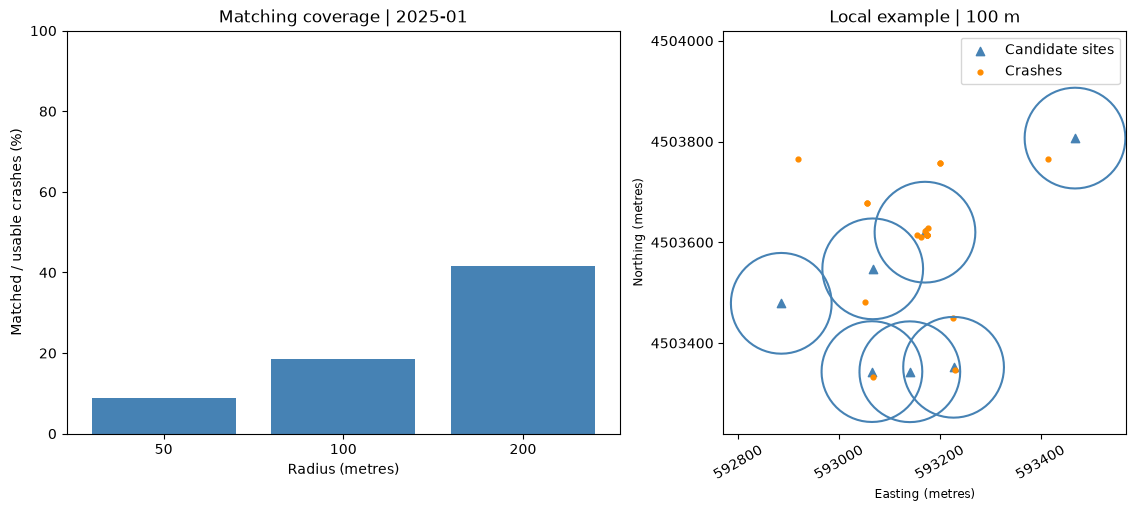

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
axes[0].bar(coverage.radius_m.astype(str), coverage.matched_percent, color="steelblue")
axes[0].set(xlabel="Radius (metres)", ylabel="Matched / usable crashes (%)", ylim=(0, 100),
            title=f"Matching coverage | {MONTH}")

top_site = metrics.sort_values(["crash_count", "site_id"], ascending=[False, True]).iloc[0].site_id
center = sites.set_index("site_id").geometry.loc[top_site]
extent = max(400, RADIUS_M * 3)
near_sites = sites[sites.geometry.distance(center) <= extent]
near_crashes = crashes[crashes.geometry.distance(center) <= extent]
buffers[buffers.site_id.isin(near_sites.site_id)].boundary.plot(ax=axes[1], color="steelblue")
near_sites.plot(ax=axes[1], marker="^", color="steelblue", label="Candidate sites")
if not near_crashes.empty:
    near_crashes.plot(ax=axes[1], color="darkorange", markersize=12, label="Crashes")
axes[1].set(xlim=(center.x-extent, center.x+extent), ylim=(center.y-extent, center.y+extent),
            xlabel="Easting (metres)", ylabel="Northing (metres)", title=f"Local example | {RADIUS_M} m")
axes[1].ticklabel_format(style="plain", useOffset=False)
axes[1].locator_params(axis="both", nbins=4)
axes[1].tick_params(axis="x", labelrotation=30)
axes[1].legend()
OUTPUT.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT / "matching_check.png", dpi=160)
plt.show()

In [13]:
shared_review = shared_sites[["site_id", "Clean_Intersection", "Latitude", "Longitude"]].copy()
shared_review = shared_review.join(all_pairs.groupby("site_id").size().rename("crashes_in_radius"), on="site_id")
shared_review = shared_review.join(nearest.groupby("site_id").size().rename("assigned_crashes"), on="site_id")
shared_review[["crashes_in_radius", "assigned_crashes"]] = shared_review[["crashes_in_radius", "assigned_crashes"]].fillna(0)

metrics.to_csv(OUTPUT / "site_month_metrics.csv", index=False)
coverage.to_csv(OUTPUT / "radius_comparison.csv", index=False)
rejected_sites.to_csv(OUTPUT / "rejected_sites.csv", index=False)
shared_groups.to_csv(OUTPUT / "shared_coordinate_groups.csv", index=False)
shared_review.to_csv(OUTPUT / "shared_coordinate_assignments.csv", index=False)
rejected_crashes.to_parquet(OUTPUT / "rejected_crashes.parquet", index=False)
all_pairs.to_parquet(OUTPUT / "all_pairs.parquet", index=False)
nearest.to_parquet(OUTPUT / "nearest.parquet", index=False)
unmatched.to_parquet(OUTPUT / "unmatched.parquet", index=False)
buffers.to_parquet(OUTPUT / "buffers.parquet", index=False)
print("Saved to:", OUTPUT.relative_to(ROOT))

Saved to: Fei/outputs/simple_2025-01_100m
